# Airbnb NYC Price Prediction — Final Project

This notebook builds a regression model for Airbnb NYC listing prices using a static tabular dataset.

The focus is on a mature modeling workflow: target analysis, robust baselines, domain-driven feature engineering, CatBoost tuning, outlier diagnostics, typical-vs-luxury segmentation, and conformal prediction intervals.

## 0. Project setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, median_absolute_error, r2_score,
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from catboost import CatBoostRegressor, CatBoostClassifier
import optuna

RANDOM_STATE = 42
DATA_PATH = Path("../data/AB_NYC_2019.csv")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 120)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Problem framing

The task is to predict listing price from features available in a static Airbnb dataset.

Assumptions:

- `price` is treated as the nightly listing price;
- the dataset does not contain seasonality, events, amenities, photos, or demand data;
- reviews and availability are behavioral variables;
- extreme prices are not removed silently;
- point predictions are complemented with uncertainty intervals.

## 2. Data loading and audit

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df_raw.shape

(48895, 16)

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
missing_summary = (
    df_raw.isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_rate")
)

missing_summary[missing_summary["missing_rate"] > 0]

,missing_rate
last_review,0.205583
reviews_per_month,0.205583
host_name,0.000429
name,0.000327


In [6]:
df_raw.duplicated().sum()

np.int64(0)

In [7]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [8]:
(df_raw["price"] <= 0).sum()

np.int64(11)

## 3. Target distribution and outliers

In [9]:
df_raw["price"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.98, 0.99, 0.995])

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
50%        106.000000
75%        175.000000
90%        269.000000
95%        355.000000
98%        550.000000
99%        799.000000
99.5%     1000.000000
max      10000.000000
Name: price, dtype: float64

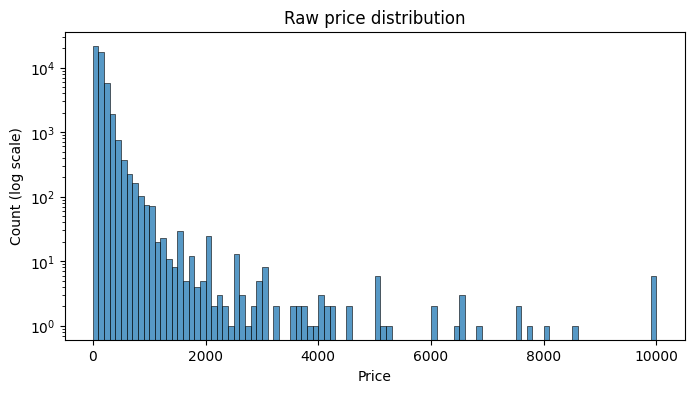

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df_raw["price"], bins=100)
plt.yscale("log")
plt.xlabel("Price")
plt.ylabel("Count (log scale)")
plt.title("Raw price distribution")
plt.show()

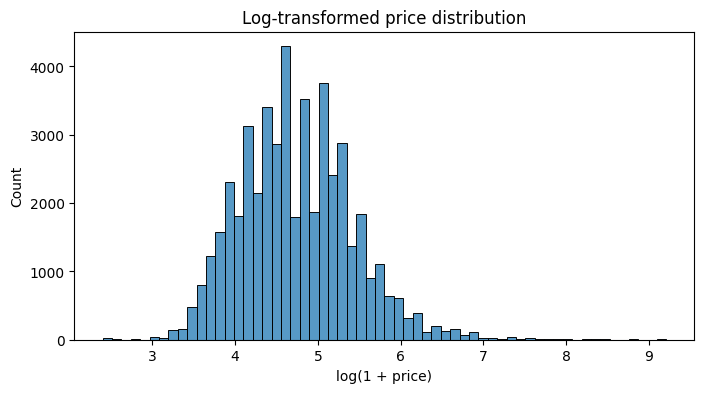

In [11]:
valid_price = df_raw.loc[df_raw["price"] > 0, "price"]

plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(valid_price), bins=60)
plt.xlabel("log(1 + price)")
plt.ylabel("Count")
plt.title("Log-transformed price distribution")
plt.show()

In [12]:
valid_price.quantile([0.50, 0.75, 0.90, 0.95, 0.98, 0.99, 0.995, 1.00])

0.500      106.0
0.750      175.0
0.900      269.0
0.950      355.0
0.980      550.0
0.990      799.0
0.995     1000.0
1.000    10000.0
Name: price, dtype: float64

In [13]:
valid_price.agg(["mean", "median", "std", "min", "max"])

mean        152.755053
median      106.000000
std         240.170260
min          10.000000
max       10000.000000
Name: price, dtype: float64

In [14]:
extreme_threshold = valid_price.quantile(0.99)

extreme_listings = (
    df_raw[df_raw["price"] >= extreme_threshold]
    .sort_values("price", ascending=False)
)

extreme_listings[
    ["name", "neighbourhood_group", "neighbourhood", "room_type",
     "price", "minimum_nights", "number_of_reviews", "availability_365"]
].head(20)

,name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365
29238,1-BR Lincoln Center,Manhattan,Upper West Side,Entire home/apt,10000,30,0,83
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Greenpoint,Entire home/apt,10000,5,5,0
9151,Furnished room in Astoria apartment,Queens,Astoria,Private room,10000,100,2,0
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Lower East Side,Entire home/apt,9999,30,0,365
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Lower East Side,Private room,9999,99,6,83
6530,Spanish Harlem Apt,Manhattan,East Harlem,Entire home/apt,9999,5,1,0
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Tribeca,Entire home/apt,8500,30,2,251
4377,Film Location,Brooklyn,Clinton Hill,Entire home/apt,8000,1,1,365
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Upper East Side,Entire home/apt,7703,1,0,146
42523,70' Luxury MotorYacht on the Hudson,Manhattan,Battery Park City,Entire home/apt,7500,1,0,364


In [15]:
(
    extreme_listings
    .groupby(["neighbourhood_group", "room_type"])
    .size()
    .sort_values(ascending=False)
    .to_frame("count")
    .head(15)
)

count
neighbourhood_group room_type             
Manhattan           Entire home/apt    304
Brooklyn            Entire home/apt     78
Manhattan           Private room        59
Brooklyn            Private room        25
Queens              Entire home/apt      9
                    Private room         4
Staten Island       Entire home/apt      4
Manhattan           Shared room          3
Queens              Shared room          3
Bronx               Entire home/apt      1
                    Private room         1
                    Shared room          1

The target is strongly right-skewed, with a long upper tail of expensive listings. Models are therefore trained on `log1p(price)` to emphasize multiplicative error structure, while evaluation reports both dollar-scale metrics and RMSLE.

Extreme listings are concentrated in specific location and room-type combinations. They are kept in the main modeling population, but are examined separately through robustness and segment diagnostics.

## 4. Cleaning policy

In [16]:
def clean_airbnb_data(df):
    df = df.copy()
    df = df[df["price"] > 0].copy()
    df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
    df["has_reviews"] = (df["number_of_reviews"] > 0).astype(int)

    # Removed because this version does not model text or date dynamics.
    drop_cols = ["id", "host_id", "name", "host_name", "last_review"]
    return df.drop(columns=drop_cols)


df = clean_airbnb_data(df_raw)
df.shape

(48884, 12)

In [17]:
df.isna().mean().sort_values(ascending=False).head()

neighbourhood_group    0.0
neighbourhood          0.0
latitude               0.0
longitude              0.0
room_type              0.0
dtype: float64

## 5. Exploratory feature analysis

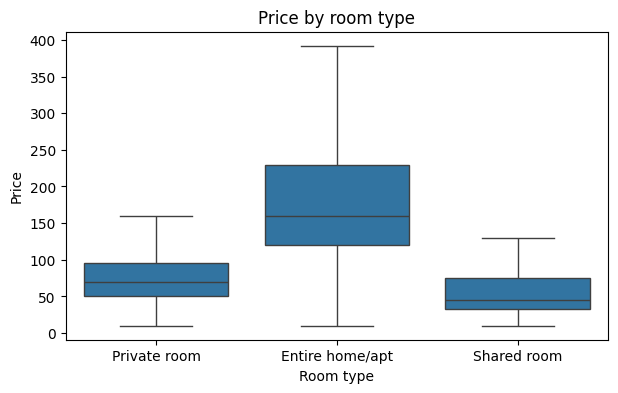

In [18]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="room_type", y="price", showfliers=False)
plt.xlabel("Room type")
plt.ylabel("Price")
plt.title("Price by room type")
plt.show()

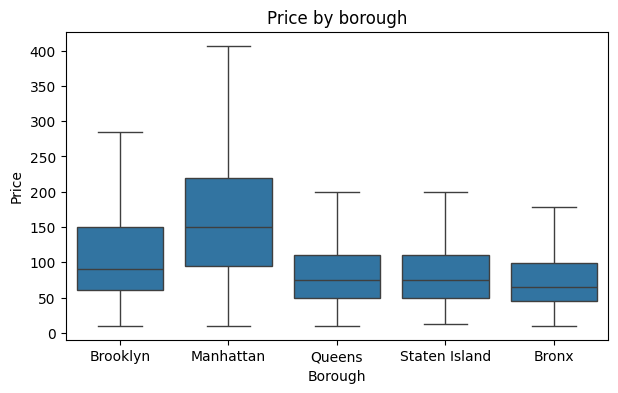

In [19]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="neighbourhood_group", y="price", showfliers=False)
plt.xlabel("Borough")
plt.ylabel("Price")
plt.title("Price by borough")
plt.show()

In [20]:
neighbourhood_summary = (
    df.groupby("neighbourhood")
    .agg(listing_count=("price", "size"), median_price=("price", "median"), mean_price=("price", "mean"))
    .query("listing_count >= 30")
    .sort_values("median_price", ascending=False)
)

neighbourhood_summary.head(15)

,listing_count,median_price,mean_price
neighbourhood,,,
Tribeca,177,295.0,490.638418
NoHo,78,250.0,295.717949
Flatiron District,80,225.0,341.925000
Midtown,1545,210.0,282.719094
West Village,768,200.0,267.682292
Financial District,744,200.0,225.490591
SoHo,358,199.0,287.103352
Chelsea,1113,199.0,249.738544
Greenwich Village,392,197.5,263.405612


In [21]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

target_corr = pd.DataFrame({
    "pearson": df[numeric_cols].corr(method="pearson")["price"],
    "spearman": df[numeric_cols].corr(method="spearman")["price"]
}).drop(index="price").sort_values("spearman", key=abs, ascending=False)

target_corr

,pearson,spearman
longitude,-0.149954,-0.437890
latitude,0.033899,0.136046
calculated_host_listings_count,0.057462,-0.105715
minimum_nights,0.042805,0.101330
availability_365,0.081847,0.086175
has_reviews,-0.085120,-0.069131
reviews_per_month,-0.050531,-0.059908
number_of_reviews,-0.047926,-0.054898


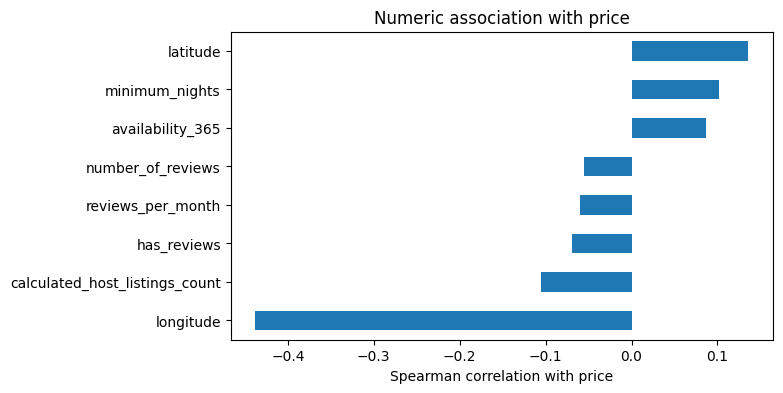

In [22]:
plt.figure(figsize=(7, 4))
target_corr["spearman"].sort_values().plot(kind="barh")
plt.xlabel("Spearman correlation with price")
plt.title("Numeric association with price")
plt.show()

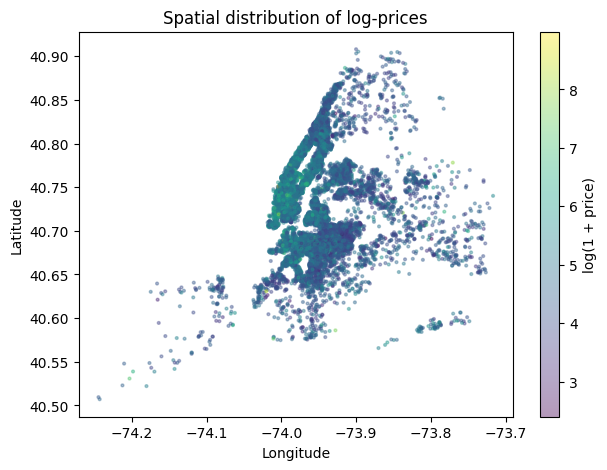

In [23]:
plot_sample = df.sample(min(15000, len(df)), random_state=RANDOM_STATE)

plt.figure(figsize=(7, 5))
plt.scatter(plot_sample["longitude"], plot_sample["latitude"], c=np.log1p(plot_sample["price"]), s=4, alpha=0.4)
plt.colorbar(label="log(1 + price)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial distribution of log-prices")
plt.show()

## 6. Feature engineering

In [24]:
NYC_ANCHORS = {
    "midtown": (40.7580, -73.9855),
    "downtown_manhattan": (40.7075, -74.0113),
    "williamsburg": (40.7081, -73.9571),
    "jfk": (40.6413, -73.7781),
    "lga": (40.7769, -73.8740),
    "central_park": (40.7812, -73.9665),
}

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

def add_features(df):
    df = df.copy()
    df["log_minimum_nights"] = np.log1p(df["minimum_nights"])
    df["log_number_of_reviews"] = np.log1p(df["number_of_reviews"])
    df["log_reviews_per_month"] = np.log1p(df["reviews_per_month"])
    df["log_host_listings_count"] = np.log1p(df["calculated_host_listings_count"])

    df["availability_ratio"] = df["availability_365"] / 365
    df["is_available"] = (df["availability_365"] > 0).astype(int)
    df["high_availability"] = (df["availability_365"] > 180).astype(int)

    df["host_type"] = pd.cut(
        df["calculated_host_listings_count"],
        bins=[0, 1, 3, 10, np.inf],
        labels=["single", "small", "medium", "professional"]
    ).astype(str)

    df["review_activity_level"] = pd.cut(
        df["reviews_per_month"],
        bins=[-0.01, 0, 0.5, 2, np.inf],
        labels=["none", "low", "medium", "high"]
    ).astype(str)

    df["minimum_nights_level"] = pd.cut(
        df["minimum_nights"],
        bins=[0, 2, 7, 30, np.inf],
        labels=["short_stay", "weekly", "monthly", "long_term"]
    ).astype(str)

    df["borough_room_type"] = df["neighbourhood_group"].astype(str) + "__" + df["room_type"].astype(str)
    df["neighbourhood_room_type"] = df["neighbourhood"].astype(str) + "__" + df["room_type"].astype(str)

    for anchor_name, (lat, lon) in NYC_ANCHORS.items():
        df[f"distance_to_{anchor_name}_km"] = haversine_distance(df["latitude"], df["longitude"], lat, lon)

    return df

df = add_features(df)
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_reviews,log_minimum_nights,log_number_of_reviews,log_reviews_per_month,log_host_listings_count,availability_ratio,is_available,high_availability,host_type,review_activity_level,minimum_nights_level,borough_room_type,neighbourhood_room_type,distance_to_midtown_km,distance_to_downtown_manhattan_km,distance_to_williamsburg_km,distance_to_jfk_km,distance_to_lga_km,distance_to_central_park_km
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,1,0.693147,2.302585,0.190620,1.945910,1.000000,1,1,medium,low,short_stay,Brooklyn__Private room,Kensington__Private room,12.337898,7.436667,6.861440,16.405201,16.607450,14.876103
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,1,0.693147,3.828641,0.322083,1.098612,0.972603,1,1,small,low,short_stay,Manhattan__Entire home/apt,Midtown__Entire home/apt,0.508366,5.628563,5.538040,21.368633,9.600200,3.394152
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,0,1.386294,0.000000,0.000000,0.693147,1.000000,1,1,single,none,weekly,Manhattan__Private room,Harlem__Private room,6.757240,12.712140,11.294584,23.202089,6.740110,3.722598
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,1,0.693147,5.602119,1.729884,0.693147,0.531507,1,1,single,high,short_stay,Brooklyn__Entire home/apt,Clinton Hill__Entire home/apt,8.387034,5.006161,2.562865,16.079270,12.503001,10.696471
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,1,2.397895,2.302585,0.095310,0.693147,0.000000,0,0,single,low,monthly,Manhattan__Entire home/apt,East Harlem__Entire home/apt,5.701496,11.599894,10.113603,22.383848,6.363550,2.701110


## 7. Train/test split and metrics

In [25]:
TARGET = "price"
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_train.shape, X_test.shape

((39107, 29), (9777, 29))

In [26]:
def regression_metrics(y_true, y_pred):
    y_pred_safe = np.maximum(y_pred, 0)
    return {
        "MAE": mean_absolute_error(y_true, y_pred_safe),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred_safe)),
        "MedAE": median_absolute_error(y_true, y_pred_safe),
        "RMSLE": np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_safe))),
        "R2": r2_score(y_true, y_pred_safe)
    }

def make_results_row(model_name, y_true, y_pred):
    row = {"Model": model_name}
    row.update(regression_metrics(y_true, y_pred))
    return row

## 8. Baseline models

The baselines estimate how much price structure is explained by simple grouping variables. Location and room type already carry meaningful signal, and the median by borough and room type is the strongest baseline.

In [27]:
baseline_results = []

global_median = y_train.median()
baseline_results.append(make_results_row("Global median", y_test, np.full(len(y_test), global_median)))

room_medians = y_train.groupby(X_train["room_type"]).median()
y_pred_room = X_test["room_type"].map(room_medians).fillna(global_median).to_numpy()
baseline_results.append(make_results_row("Median by room type", y_test, y_pred_room))

group_cols = ["neighbourhood_group", "room_type"]
group_medians = pd.concat([X_train[group_cols], y_train], axis=1).groupby(group_cols)["price"].median()
y_pred_group = (
    X_test[group_cols]
    .merge(group_medians.rename("pred").reset_index(), on=group_cols, how="left")["pred"]
    .fillna(global_median)
    .to_numpy()
)

baseline_results.append(make_results_row("Median by borough and room type", y_test, y_pred_group))

baseline_results = pd.DataFrame(baseline_results)
baseline_results

,Model,MAE,RMSE,MedAE,RMSLE,R2
0,Global median,82.730899,205.100619,46.0,0.695838,-0.050712
1,Median by room type,66.757288,194.802415,30.0,0.550256,0.052152
2,Median by borough and room type,63.514319,192.195455,30.0,0.519740,0.077352


## 9. Lightweight benchmark models

In [28]:
numeric_features = [
    "latitude", "longitude",
    "minimum_nights", "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365", "has_reviews",
    "log_minimum_nights", "log_number_of_reviews", "log_reviews_per_month",
    "log_host_listings_count", "availability_ratio", "is_available", "high_availability",
    "distance_to_midtown_km", "distance_to_downtown_manhattan_km",
    "distance_to_williamsburg_km", "distance_to_jfk_km", "distance_to_lga_km",
    "distance_to_central_park_km"
]

low_cardinality_features = [
    "neighbourhood_group", "room_type", "host_type",
    "review_activity_level", "minimum_nights_level", "borough_room_type"
]

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

benchmark_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", make_one_hot_encoder(), low_cardinality_features)
    ],
    remainder="drop",
    sparse_threshold=0
)

benchmark_models = {
    "Ridge": Ridge(alpha=10.0, solver="lsqr"),
    "Huber regression": HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=1000),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=16,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

benchmark_results = []

for name, model in benchmark_models.items():
    pipe = Pipeline([("preprocessor", benchmark_preprocessor), ("model", model)])
    pipe.fit(X_train, y_train_log)
    pred = np.expm1(pipe.predict(X_test))
    benchmark_results.append(make_results_row(name, y_test, pred))

benchmark_results = pd.DataFrame(benchmark_results)
benchmark_results

,Model,MAE,RMSE,MedAE,RMSLE,R2
0,Ridge,59.186304,185.562763,26.695832,0.469400,0.139934
1,Huber regression,58.565730,187.547476,24.664708,0.473237,0.121438
2,Random Forest,55.447439,177.764799,23.376619,0.438373,0.210701


The benchmark models are intentionally lightweight and not heavily tuned. They provide reference points for common modeling families; CatBoost is the only model tuned with Optuna because it handles mixed tabular data and high-value categorical variables such as `neighbourhood`, `room_type`, and `neighbourhood_room_type` especially well.

## 10. CatBoost feature set

In [29]:
catboost_features = numeric_features + low_cardinality_features + ["neighbourhood", "neighbourhood_room_type"]
catboost_categorical_features = low_cardinality_features + ["neighbourhood", "neighbourhood_room_type"]

def prepare_catboost_frame(X):
    X_cb = X[catboost_features].copy()
    for col in catboost_categorical_features:
        X_cb[col] = X_cb[col].astype(str).fillna("missing")
    return X_cb

X_train_cb = prepare_catboost_frame(X_train)
X_test_cb = prepare_catboost_frame(X_test)

cat_feature_indices = [X_train_cb.columns.get_loc(col) for col in catboost_categorical_features]
X_train_cb.head()

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_reviews,log_minimum_nights,log_number_of_reviews,log_reviews_per_month,log_host_listings_count,availability_ratio,is_available,high_availability,distance_to_midtown_km,distance_to_downtown_manhattan_km,distance_to_williamsburg_km,distance_to_jfk_km,distance_to_lga_km,distance_to_central_park_km,neighbourhood_group,room_type,host_type,review_activity_level,minimum_nights_level,borough_room_type,neighbourhood,neighbourhood_room_type
44559,40.70840,-73.78882,3,6,3.05,1,37,1,1.386294,1.945910,1.398717,0.693147,0.101370,1,0,17.465652,18.753241,14.184400,7.515750,10.464861,17.017161,Queens,Entire home/apt,single,high,weekly,Queens__Entire home/apt,Jamaica,Jamaica__Entire home/apt
31363,40.70343,-73.93412,5,5,0.35,1,0,1,1.791759,1.791759,0.300105,0.693147,0.000000,0,0,7.454056,6.521515,2.005458,14.861430,9.612274,9.067693,Brooklyn,Private room,single,low,weekly,Brooklyn__Private room,Williamsburg,Williamsburg__Private room
42274,40.89981,-73.86684,2,7,1.84,1,70,1,1.098612,2.079442,1.043804,0.693147,0.191781,1,0,18.663389,24.599074,22.630461,29.700491,13.680235,15.627889,Bronx,Private room,single,medium,short_stay,Bronx__Private room,Woodlawn,Woodlawn__Private room
11756,40.74526,-73.99545,14,1,0.02,1,0,1,2.708050,0.693147,0.019803,0.693147,0.000000,0,0,1.645996,4.406039,5.245658,21.666107,10.817055,4.681403,Manhattan,Private room,single,low,monthly,Manhattan__Private room,Chelsea,Chelsea__Private room
23350,40.67075,-73.97690,1,0,0.00,4,0,0,0.693147,0.000000,0.000000,1.609438,0.000000,0,0,9.728796,5.011107,4.476098,17.086766,14.646250,12.312709,Brooklyn,Private room,medium,none,short_stay,Brooklyn__Private room,Park Slope,Park Slope__Private room


## 11. Untuned CatBoost

In [30]:
cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=800,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    random_seed=RANDOM_STATE,
    verbose=False
)

cat_model.fit(X_train_cb, y_train_log, cat_features=cat_feature_indices)

cat_pred = np.expm1(cat_model.predict(X_test_cb))
cat_metrics = make_results_row("CatBoost", y_test, cat_pred)
cat_metrics

{'Model': 'CatBoost',
 'MAE': 55.710210031406476,
 'RMSE': np.float64(179.6924638499041),
 'MedAE': np.float64(23.975916512906338),
 'RMSLE': np.float64(0.4382009109050936),
 'R2': 0.1934902945713003}

## 12. Optuna tuning for CatBoost

In [31]:
def catboost_objective(trial):
    params = {
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "iterations": trial.suggest_int("iterations", 500, 1200),
        "depth": trial.suggest_int("depth", 4, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.12, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 40),
        "random_seed": RANDOM_STATE,
        "verbose": False
    }

    scores = []
    for train_idx, valid_idx in cv.split(X_train_cb):
        X_tr = X_train_cb.iloc[train_idx]
        X_val = X_train_cb.iloc[valid_idx]
        y_tr = y_train_log.iloc[train_idx]
        y_val = y_train_log.iloc[valid_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, cat_features=cat_feature_indices)

        pred_val = model.predict(X_val)
        scores.append(np.sqrt(mean_squared_error(y_val, pred_val)))

    return float(np.mean(scores))

study = optuna.create_study(direction="minimize")
study.optimize(catboost_objective, n_trials=30, show_progress_bar=False)

best_cat_params = study.best_params
best_cat_params

{'iterations': 918,
 'depth': 9,
 'learning_rate': 0.045079778261439135,
 'l2_leaf_reg': 2.813462266782539,
 'random_strength': 0.5438013335577696,
 'bagging_temperature': 1.70065392972416,
 'min_data_in_leaf': 12}

In [36]:
tuned_cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    **best_cat_params
)

tuned_cat_model.fit(X_train_cb, y_train_log, cat_features=cat_feature_indices)

tuned_cat_pred = np.expm1(tuned_cat_model.predict(X_test_cb))
tuned_cat_metrics = make_results_row("Tuned CatBoost", y_test, tuned_cat_pred)
tuned_cat_metrics

{'Model': 'Tuned CatBoost',
 'MAE': 54.82736352707037,
 'RMSE': np.float64(176.45566494192536),
 'MedAE': np.float64(23.441481897712777),
 'RMSLE': np.float64(0.43166571664006853),
 'R2': 0.22228391376874745}

In [37]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

tuned_cat_model.save_model(MODEL_DIR / "tuned_catboost_airbnb.cbm")

## 13. Model comparison

In [38]:
model_results = pd.concat(
    [baseline_results, benchmark_results, pd.DataFrame([cat_metrics, tuned_cat_metrics])],
    ignore_index=True
)

model_results.sort_values("MAE")

,Model,MAE,RMSE,MedAE,RMSLE,R2
7,Tuned CatBoost,54.827364,176.455665,23.441482,0.431666,0.222284
5,Random Forest,55.447439,177.764799,23.376619,0.438373,0.210701
6,CatBoost,55.710210,179.692464,23.975917,0.438201,0.193490
4,Huber regression,58.565730,187.547476,24.664708,0.473237,0.121438
3,Ridge,59.186304,185.562763,26.695832,0.469400,0.139934
2,Median by borough and room type,63.514319,192.195455,30.000000,0.519740,0.077352
1,Median by room type,66.757288,194.802415,30.000000,0.550256,0.052152
0,Global median,82.730899,205.100619,46.000000,0.695838,-0.050712


In [34]:
final_model = tuned_cat_model
final_model_name = "Tuned CatBoost"
final_pred = tuned_cat_pred

final_metrics = make_results_row(final_model_name, y_test, final_pred)
final_metrics

{'Model': 'Tuned CatBoost',
 'MAE': 54.82736352707037,
 'RMSE': np.float64(176.45566494192536),
 'MedAE': np.float64(23.441481897712777),
 'RMSLE': np.float64(0.43166571664006853),
 'R2': 0.22228391376874745}

## 14. Robustness experiments: outlier removal

In [39]:
def fit_catboost_on_split(X_train_regime, y_train_regime, X_test_regime):
    X_train_regime_cb = prepare_catboost_frame(X_train_regime)
    X_test_regime_cb = prepare_catboost_frame(X_test_regime)

    model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        **best_cat_params
    )

    model.fit(X_train_regime_cb, np.log1p(y_train_regime), cat_features=cat_feature_indices)
    return np.expm1(model.predict(X_test_regime_cb))

def evaluate_trim_regime(X, y, regime_name, trim_quantile=None):
    if trim_quantile is not None:
        threshold = y.quantile(trim_quantile)
        mask = y <= threshold
        X_regime = X[mask]
        y_regime = y[mask]
    else:
        threshold = np.nan
        X_regime = X.copy()
        y_regime = y.copy()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_regime, y_regime, test_size=0.20, random_state=RANDOM_STATE
    )

    pred = fit_catboost_on_split(X_tr, y_tr, X_te)

    row = make_results_row(regime_name, y_te, pred)
    row["price_cap"] = threshold
    row["n_samples"] = len(X_regime)
    return row

robustness_results = pd.DataFrame([
    evaluate_trim_regime(X, y, "All valid prices", None),
    evaluate_trim_regime(X, y, "Trim above 99th percentile", 0.99),
    evaluate_trim_regime(X, y, "Trim above 98th percentile", 0.98),
    evaluate_trim_regime(X, y, "Trim above 95th percentile", 0.95),
])

robustness_results

,Model,MAE,RMSE,MedAE,RMSLE,R2,price_cap,n_samples
0,All valid prices,54.827364,176.455665,23.441482,0.431666,0.222284,NaN,48884
1,Trim above 99th percentile,41.425419,72.546244,22.252132,0.379641,0.516358,799.0,48410
2,Trim above 98th percentile,37.836346,61.919583,21.163896,0.367796,0.520465,550.0,47949
3,Trim above 95th percentile,31.958818,47.379395,20.115849,0.341891,0.568986,355.0,46443


Trimming high-price listings sharply improves the reported metrics, but this is not a pure model improvement. It changes the target population by excluding expensive listings, so the correct conclusion is that the model performs much better on typical listings than on the full market.

## 15. Global model diagnostics by price segment

Segment diagnostics separate typical listings from the upper-tail luxury segment. The global CatBoost model is well centered for typical listings, with a mean residual close to zero, but it strongly underpredicts luxury listings.

In [40]:
luxury_threshold = y_train.quantile(0.95)
luxury_threshold

np.float64(355.6999999999971)

In [41]:
segment_eval = pd.DataFrame({"y_true": y_test, "y_pred": final_pred})
segment_eval["segment"] = np.where(segment_eval["y_true"] >= luxury_threshold, "luxury", "typical")
segment_eval["residual"] = segment_eval["y_true"] - segment_eval["y_pred"]
segment_eval["abs_error"] = segment_eval["residual"].abs()

segment_rows = []
for segment_name, group in segment_eval.groupby("segment"):
    row = make_results_row(f"Global model on {segment_name}", group["y_true"], group["y_pred"])
    row["count"] = len(group)
    row["mean_residual"] = group["residual"].mean()
    segment_rows.append(row)

segment_results = pd.DataFrame(segment_rows)
segment_results

,Model,MAE,RMSE,MedAE,RMSLE,R2,count,mean_residual
0,Global model on luxury,446.108575,760.702586,262.340088,1.142403,-0.460472,485,442.839649
1,Global model on typical,34.404270,50.576071,21.842020,0.357689,0.514043,9292,-1.574349


## 16. Luxury classifier and threshold tuning

In [42]:
# Split the original training set into:
# 1. segment-training data: trains classifier + typical/luxury regressors
# 2. routing-validation data: selects the classification threshold

X_seg_train, X_route_val, y_seg_train, y_route_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=RANDOM_STATE
)

luxury_threshold = y_seg_train.quantile(0.95)

y_seg_train_luxury = (y_seg_train >= luxury_threshold).astype(int)
y_route_val_luxury = (y_route_val >= luxury_threshold).astype(int)
y_test_luxury = (y_test >= luxury_threshold).astype(int)

X_seg_train_cb = prepare_catboost_frame(X_seg_train)
X_route_val_cb = prepare_catboost_frame(X_route_val)
X_test_cb = prepare_catboost_frame(X_test)

luxury_threshold

np.float64(352.0)

In [43]:
luxury_classifier = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=700,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    random_seed=RANDOM_STATE,
    verbose=False
)

luxury_classifier.fit(
    X_seg_train_cb,
    y_seg_train_luxury,
    cat_features=cat_feature_indices
)

luxury_proba_route_val = luxury_classifier.predict_proba(X_route_val_cb)[:, 1]
luxury_proba_test = luxury_classifier.predict_proba(X_test_cb)[:, 1]

classifier_validation_metrics = {
    "AUC": roc_auc_score(y_route_val_luxury, luxury_proba_route_val),
    "Accuracy@0.5": accuracy_score(y_route_val_luxury, luxury_proba_route_val >= 0.5),
    "Precision@0.5": precision_score(y_route_val_luxury, luxury_proba_route_val >= 0.5, zero_division=0),
    "Recall@0.5": recall_score(y_route_val_luxury, luxury_proba_route_val >= 0.5, zero_division=0),
    "F1@0.5": f1_score(y_route_val_luxury, luxury_proba_route_val >= 0.5, zero_division=0)
}

classifier_validation_metrics

{'AUC': np.float64(0.8790682332650641),
 'Accuracy@0.5': 0.9524393985885241,
 'Precision@0.5': 0.6767676767676768,
 'Recall@0.5': 0.134,
 'F1@0.5': 0.22370617696160267}

In [ ]:
typical_mask_seg_train = y_seg_train < luxury_threshold
luxury_mask_seg_train = y_seg_train >= luxury_threshold

X_typical_train = X_seg_train[typical_mask_seg_train]
y_typical_train = y_seg_train[typical_mask_seg_train]

X_luxury_train = X_seg_train[luxury_mask_seg_train]
y_luxury_train = y_seg_train[luxury_mask_seg_train]

len(X_typical_train), len(X_luxury_train)

(27862, 1468)

In [45]:
typical_regressor = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    **best_cat_params
)

typical_regressor.fit(
    prepare_catboost_frame(X_typical_train),
    np.log1p(y_typical_train),
    cat_features=cat_feature_indices
)

luxury_regressor = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    **best_cat_params
)

luxury_regressor.fit(
    prepare_catboost_frame(X_luxury_train),
    np.log1p(y_luxury_train),
    cat_features=cat_feature_indices
)

CatBoostRegressor(bagging_temperature=1.70065392972416, depth=9, eval_metric='RMSE', iterations=918, l2_leaf_reg=2.813462266782539, learning_rate=0.045079778261439135, loss_function='RMSE', min_data_in_leaf=12, random_seed=42, random_strength=0.5438013335577696, verbose=False)

In [46]:
typical_pred_route_val = np.expm1(typical_regressor.predict(X_route_val_cb))
luxury_pred_route_val = np.expm1(luxury_regressor.predict(X_route_val_cb))

typical_pred_test = np.expm1(typical_regressor.predict(X_test_cb))
luxury_pred_test = np.expm1(luxury_regressor.predict(X_test_cb))

In [60]:
threshold_rows = []
threshold_grid = np.linspace(0.02, 0.70, 35)

for threshold in threshold_grid:
    is_luxury_pred_val = luxury_proba_route_val >= threshold

    hard_pred_val = np.where(
        is_luxury_pred_val,
        luxury_pred_route_val,
        typical_pred_route_val
    )

    hard_metrics = regression_metrics(y_route_val, hard_pred_val)

    threshold_rows.append({
        "threshold": threshold,
        "predicted_luxury_rate": is_luxury_pred_val.mean(),
        "precision": precision_score(y_route_val_luxury, is_luxury_pred_val, zero_division=0),
        "recall": recall_score(y_route_val_luxury, is_luxury_pred_val, zero_division=0),
        "f1": f1_score(y_route_val_luxury, is_luxury_pred_val, zero_division=0),
        "validation_MAE": hard_metrics["MAE"],
        "validation_RMSE": hard_metrics["RMSE"],
        "validation_RMSLE": hard_metrics["RMSLE"]
    })

threshold_results = pd.DataFrame(threshold_rows)

threshold_results.sort_values("validation_MAE").head(10)

,threshold,predicted_luxury_rate,precision,recall,f1,validation_MAE,validation_RMSE,validation_RMSLE
25,0.52,0.009103,0.707865,0.126,0.213922,55.759034,198.138428,0.443033
31,0.64,0.004909,0.770833,0.074,0.135036,55.767082,199.450257,0.444338
32,0.66,0.004705,0.760870,0.070,0.128205,55.789316,199.470286,0.444432
33,0.68,0.003989,0.820513,0.064,0.118738,55.789628,200.036627,0.444771
29,0.60,0.005932,0.758621,0.088,0.157706,55.789791,199.401126,0.444190
28,0.58,0.006239,0.754098,0.092,0.163993,55.799817,198.239122,0.443547
26,0.54,0.008080,0.721519,0.114,0.196891,55.803346,198.305852,0.443462
34,0.70,0.003887,0.815789,0.062,0.115242,55.811039,200.050752,0.444862
30,0.62,0.005216,0.745098,0.076,0.137931,55.868850,199.609391,0.444672
27,0.56,0.007057,0.724638,0.100,0.175747,55.909356,198.462676,0.444014


In [63]:
best_threshold = (
    threshold_results
    .sort_values("validation_MAE")
    .iloc[0]["threshold"]
)

best_threshold

np.float64(0.5199999999999999)

In [64]:
hard_segment_pred = np.where(
    luxury_proba_test >= best_threshold,
    luxury_pred_test,
    typical_pred_test
)

blended_segment_pred = (
    luxury_proba_test * luxury_pred_test
    + (1 - luxury_proba_test) * typical_pred_test
)

segmented_results = pd.DataFrame([
    make_results_row("Global CatBoost", y_test, final_pred),
    make_results_row("Hard-routed segmented CatBoost", y_test, hard_segment_pred),
    make_results_row("Probability-blended segmented CatBoost", y_test, blended_segment_pred)
])

segmented_results

,Model,MAE,RMSE,MedAE,RMSLE,R2
0,Global CatBoost,54.827364,176.455665,23.441482,0.431666,0.222284
1,Hard-routed segmented CatBoost,55.611096,181.599749,21.884707,0.448327,0.176279
2,Probability-blended segmented CatBoost,57.110111,176.412005,25.788770,0.441218,0.222669


In [50]:
segmented_eval = pd.DataFrame({
    "y_true": y_test,
    "global_pred": final_pred,
    "hard_segment_pred": hard_segment_pred,
    "blended_segment_pred": blended_segment_pred,
    "is_luxury": y_test_luxury
})

segment_model_rows = []

for segment_value, segment_name in [(0, "typical"), (1, "luxury")]:
    mask = segmented_eval["is_luxury"] == segment_value

    for pred_col, model_name in [
        ("global_pred", "Global CatBoost"),
        ("hard_segment_pred", "Hard-routed segmented CatBoost"),
        ("blended_segment_pred", "Probability-blended segmented CatBoost")
    ]:
        row = make_results_row(
            f"{model_name} on {segment_name}",
            segmented_eval.loc[mask, "y_true"],
            segmented_eval.loc[mask, pred_col]
        )
        row["count"] = int(mask.sum())
        row["mean_residual"] = (
            segmented_eval.loc[mask, "y_true"]
            - segmented_eval.loc[mask, pred_col]
        ).mean()
        segment_model_rows.append(row)

segment_model_comparison = pd.DataFrame(segment_model_rows)
segment_model_comparison

,Model,MAE,RMSE,MedAE,RMSLE,R2,count,mean_residual
0,Global CatBoost on typical,34.342196,50.418480,21.826294,0.357258,0.515619,9289,-1.648042
1,Hard-routed segmented CatBoost on typical,33.410028,54.727342,20.492044,0.352770,0.429289,9289,5.932191
2,Probability-blended segmented CatBoost on typical,37.481678,56.454428,24.002406,0.377342,0.392700,9289,-8.833403
3,Global CatBoost on luxury,444.759160,758.570839,261.640138,1.141802,-0.458683,488,441.510330
4,Hard-routed segmented CatBoost on luxury,478.204783,776.986049,283.892308,1.287679,-0.530365,488,461.615962
5,Probability-blended segmented CatBoost on luxury,430.734100,750.228019,244.808204,1.090846,-0.426774,488,424.939751


The luxury segment is a clear failure mode of the global model: the model performs well on typical listings but strongly underpredicts expensive listings. A two-stage segmented approach was therefore tested with a luxury classifier and separate regressors for typical and luxury listings.

The routing threshold was selected on a validation split from the training data, not on the test set. Thresholds optimized for validation MAE, validation RMSE, and classifier F1 were tested. None of the resulting segmented models improved held-out test performance over the global CatBoost model.

This suggests that although luxury listings are a distinct error segment, the available features are not sufficient to route and price them reliably. The luxury regressor is also trained on a small subset of the data, which likely increases variance. Therefore, the tuned global CatBoost model remains the final point-prediction model, while segmentation is retained as a diagnostic experiment.

## 17. Residual analysis

The actual-vs-predicted plots show regression to the mean: low prices are sometimes overpredicted, while high prices are systematically underpredicted. On the log scale, the model captures the broad multiplicative structure of prices, but it still struggles with the upper tail.

In [65]:
candidate_predictions = {
    "Global CatBoost": final_pred,
    "Hard-routed segmented CatBoost": hard_segment_pred,
    "Probability-blended segmented CatBoost": blended_segment_pred
}

candidate_scores = {name: regression_metrics(y_test, pred)["MAE"] for name, pred in candidate_predictions.items()}

diagnostic_model_name = min(candidate_scores, key=candidate_scores.get)
diagnostic_pred = candidate_predictions[diagnostic_model_name]

diagnostic_model_name, candidate_scores

('Global CatBoost',
 {'Global CatBoost': 54.82736352707037,
  'Hard-routed segmented CatBoost': 55.61109610063001,
  'Probability-blended segmented CatBoost': 57.11011064242103})

In [66]:
error_df = X_test.copy()
error_df["y_true"] = y_test
error_df["y_pred"] = diagnostic_pred
error_df["residual"] = error_df["y_true"] - error_df["y_pred"]
error_df["abs_error"] = error_df["residual"].abs()
error_df["ape"] = error_df["abs_error"] / error_df["y_true"]
error_df["segment"] = np.where(y_test >= luxury_threshold, "luxury", "typical")

error_df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_reviews,log_minimum_nights,log_number_of_reviews,log_reviews_per_month,log_host_listings_count,availability_ratio,is_available,high_availability,host_type,review_activity_level,minimum_nights_level,borough_room_type,neighbourhood_room_type,distance_to_midtown_km,distance_to_downtown_manhattan_km,distance_to_williamsburg_km,distance_to_jfk_km,distance_to_lga_km,distance_to_central_park_km,y_true,y_pred,residual,abs_error,ape,segment
41320,Manhattan,Chelsea,40.73778,-73.99616,Private room,12,4,0.79,4,29,1,2.564949,1.609438,0.582216,1.609438,0.079452,1,0,medium,medium,monthly,Manhattan__Private room,Chelsea__Private room,2.421060,3.600616,4.661193,21.286565,11.171023,5.436085,99,90.975062,8.024938,8.024938,0.081060,typical
22079,Manhattan,East Harlem,40.79142,-73.94664,Private room,2,110,4.04,4,237,1,1.098612,4.709530,1.617406,1.609438,0.649315,1,1,medium,high,short_stay,Manhattan__Private room,East Harlem__Private room,4.951491,10.804835,9.306567,21.918282,6.325385,2.021671,90,89.443440,0.556560,0.556560,0.006184,typical
18778,Brooklyn,Williamsburg,40.71906,-73.94394,Entire home/apt,30,10,0.32,8,97,1,3.433987,2.397895,0.277632,2.197225,0.265753,1,0,medium,low,monthly,Brooklyn__Entire home/apt,Williamsburg__Entire home/apt,5.568560,5.821059,1.647872,16.441738,8.722212,7.166226,80,99.366163,-19.366163,19.366163,0.242077,typical
25494,Manhattan,Washington Heights,40.84590,-73.94219,Private room,1,1,0.04,1,0,1,0.693147,0.693147,0.039221,0.693147,0.000000,0,0,single,low,short_stay,Manhattan__Private room,Washington Heights__Private room,10.431739,16.452879,15.374009,26.621088,9.581271,7.479548,60,56.265020,3.734980,3.734980,0.062250,typical
44319,Manhattan,Harlem,40.81249,-73.94175,Private room,4,0,0.00,2,365,0,1.609438,0.000000,0.000000,1.098612,1.000000,1,1,small,none,weekly,Manhattan__Private room,Harlem__Private room,7.090789,13.061574,11.679414,23.505719,6.941774,4.055371,90,115.888690,-25.888690,25.888690,0.287652,typical


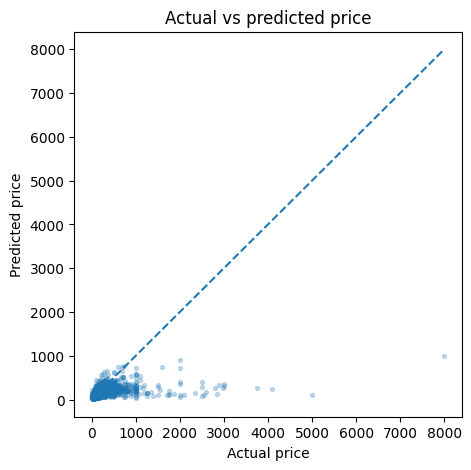

In [67]:
plt.figure(figsize=(5, 5))
plt.scatter(error_df["y_true"], error_df["y_pred"], alpha=0.25, s=8)
plt.plot([error_df["y_true"].min(), error_df["y_true"].max()], [error_df["y_true"].min(), error_df["y_true"].max()], linestyle="--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs predicted price")
plt.show()

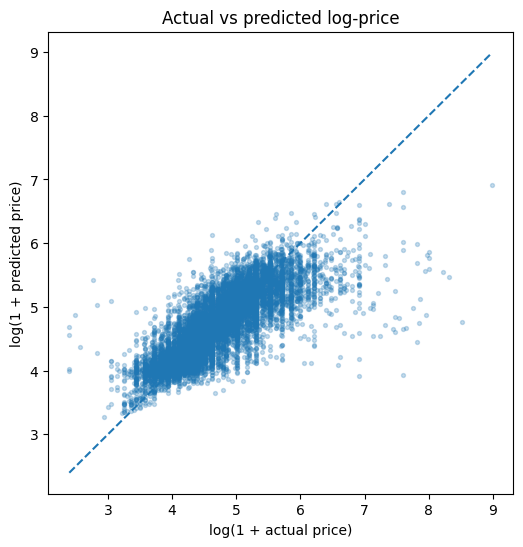

In [80]:
plt.figure(figsize=(6, 6))
plt.scatter(np.log1p(y_test), np.log1p(diagnostic_pred), alpha=0.25, s=8)
plt.plot(
    [np.log1p(y_test).min(), np.log1p(y_test).max()],
    [np.log1p(y_test).min(), np.log1p(y_test).max()],
    linestyle="--"
)
plt.xlabel("log(1 + actual price)")
plt.ylabel("log(1 + predicted price)")
plt.title("Actual vs predicted log-price")
plt.show()

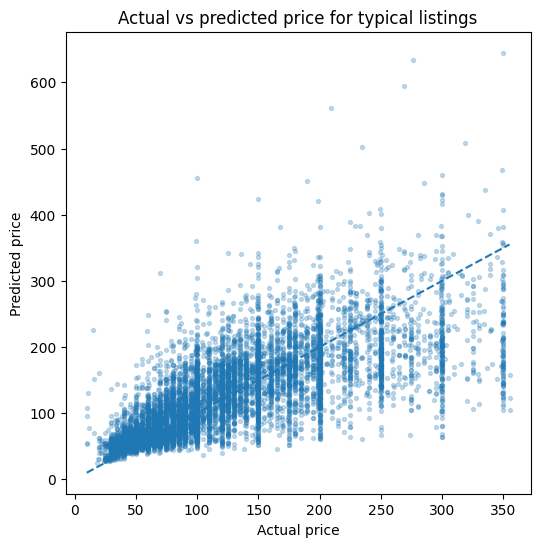

In [81]:
mask = y_test <= y_train.quantile(0.95)

plt.figure(figsize=(6, 6))
plt.scatter(y_test[mask], diagnostic_pred[mask], alpha=0.25, s=8)
plt.plot(
    [y_test[mask].min(), y_test[mask].max()],
    [y_test[mask].min(), y_test[mask].max()],
    linestyle="--"
)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs predicted price for typical listings")
plt.show()

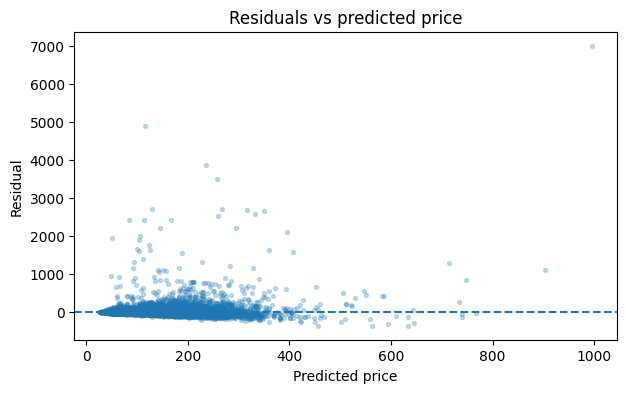

In [68]:
plt.figure(figsize=(7, 4))
plt.scatter(error_df["y_pred"], error_df["residual"], alpha=0.25, s=8)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted price")
plt.ylabel("Residual")
plt.title("Residuals vs predicted price")
plt.show()

In [69]:
def grouped_error_summary(df, group_col):
    return (
        df.groupby(group_col)
        .agg(
            count=("abs_error", "size"),
            mae=("abs_error", "mean"),
            median_ae=("abs_error", "median"),
            mean_residual=("residual", "mean"),
            mape=("ape", "mean")
        )
        .sort_values("mae", ascending=False)
    )

grouped_error_summary(error_df, "room_type")

,count,mae,median_ae,mean_residual,mape
room_type,,,,,
Entire home/apt,5039,77.262728,39.623651,28.283862,0.340484
Shared room,226,34.901990,10.080310,20.033725,0.333609
Private room,4512,30.769592,14.344606,11.768257,0.287727


In [70]:
grouped_error_summary(error_df, "neighbourhood_group")

,count,mae,median_ae,mean_residual,mape
neighbourhood_group,,,,,
Manhattan,4316,68.926759,32.507770,23.303427,0.325465
Staten Island,81,60.144624,23.917450,28.403680,0.416228
Brooklyn,4036,46.061796,19.620345,19.242755,0.303948
Queens,1120,37.129971,15.951759,16.093294,0.314422
Bronx,224,27.663168,14.691191,7.061787,0.321492


In [71]:
grouped_error_summary(error_df, "segment")

,count,mae,median_ae,mean_residual,mape
segment,,,,,
luxury,488,444.759160,261.640138,441.510330,0.546863
typical,9289,34.342196,21.826294,-1.648042,0.303849


In [72]:
error_df["price_quantile"] = pd.qcut(error_df["y_true"], q=5, duplicates="drop")

(
    error_df
    .groupby("price_quantile")
    .agg(
        count=("abs_error", "size"),
        mae=("abs_error", "mean"),
        median_ae=("abs_error", "median"),
        mean_residual=("residual", "mean"),
        rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2)))
    )
)

,count,mae,median_ae,mean_residual,rmse
price_quantile,,,,,
"(9.999, 60.0]",2056,16.748428,11.852586,-15.380428,24.836196
"(60.0, 90.0]",1959,22.141048,15.012603,-11.455120,32.399029
"(90.0, 130.0]",1930,32.357588,24.897952,-14.615226,43.734997
"(130.0, 199.8]",1876,39.078559,31.441052,-2.798963,50.977725
"(199.8, 8000.0]",1956,164.865302,84.080886,147.070226,386.724460


In [73]:
worst_predictions = (
    error_df
    .sort_values("abs_error", ascending=False)
    [[
        "neighbourhood_group", "neighbourhood", "room_type", "segment",
        "y_true", "y_pred", "residual", "abs_error",
        "minimum_nights", "number_of_reviews", "availability_365"
    ]]
)

worst_predictions.head(20)

,neighbourhood_group,neighbourhood,room_type,segment,y_true,y_pred,residual,abs_error,minimum_nights,number_of_reviews,availability_365
4377,Brooklyn,Clinton Hill,Entire home/apt,luxury,8000,996.274462,7003.725538,7003.725538,1,1,365
26739,Brooklyn,Bedford-Stuyvesant,Entire home/apt,luxury,5000,116.537188,4883.462812,4883.462812,2,8,0
42736,Manhattan,Hell's Kitchen,Entire home/apt,luxury,4100,236.213207,3863.786793,3863.786793,30,0,180
3788,Manhattan,East Village,Entire home/apt,luxury,3750,257.241194,3492.758806,3492.758806,1,0,0
30824,Manhattan,Nolita,Entire home/apt,luxury,2990,267.317310,2722.682690,2722.682690,2,69,237
41770,Manhattan,West Village,Private room,luxury,2850,129.741286,2720.258714,2720.258714,100,0,270
28858,Manhattan,SoHo,Entire home/apt,luxury,3000,317.309065,2682.690935,2682.690935,7,1,325
38947,Manhattan,Theater District,Entire home/apt,luxury,3000,349.532089,2650.467911,2650.467911,1,0,311
22992,Manhattan,Upper West Side,Entire home/apt,luxury,2900,332.331437,2567.668563,2567.668563,1,0,180
22373,Manhattan,Chelsea,Private room,luxury,2800,260.419989,2539.580011,2539.580011,1,0,89


## 18. Model interpretation

In [74]:
feature_importance = pd.DataFrame({
    "feature": X_train_cb.columns,
    "importance": final_model.get_feature_importance()
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
22,room_type,36.363929
15,distance_to_midtown_km,7.277904
12,availability_ratio,4.791016
6,availability_365,4.771685
1,longitude,4.254203
16,distance_to_downtown_manhattan_km,3.719561
25,minimum_nights_level,3.229810
27,neighbourhood,2.786720
18,distance_to_jfk_km,2.628791
23,host_type,2.558848


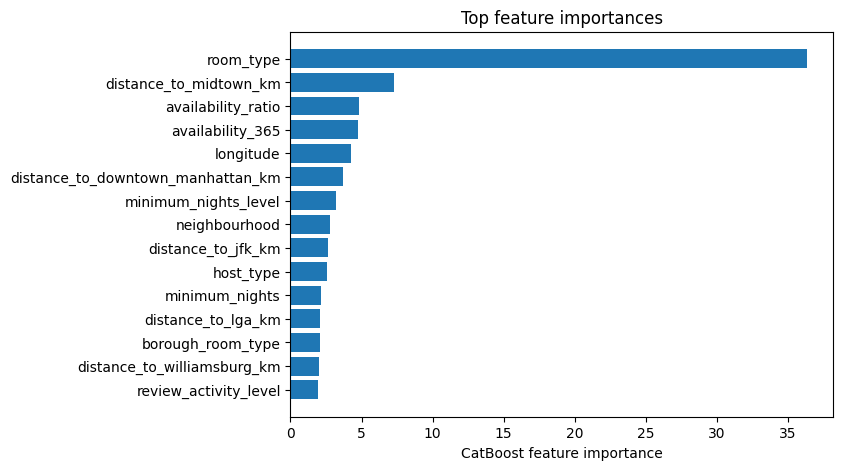

In [75]:
plt.figure(figsize=(7, 5))
top_importance = feature_importance.head(15).sort_values("importance")
plt.barh(top_importance["feature"], top_importance["importance"])
plt.xlabel("CatBoost feature importance")
plt.title("Top feature importances")
plt.show()

## 19. Segment-wise conformal prediction intervals

Conformal prediction intervals are included because individual listing prices remain uncertain even when the point model is useful. Both global and segment-wise intervals are evaluated against the intended 90% coverage level.

In [76]:
X_base, X_calib, y_base, y_calib = train_test_split(
    X_train, y_train, test_size=0.25, random_state=RANDOM_STATE
)

X_base_cb = prepare_catboost_frame(X_base)
X_calib_cb = prepare_catboost_frame(X_calib)

conformal_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    **best_cat_params
)

conformal_model.fit(X_base_cb, np.log1p(y_base), cat_features=cat_feature_indices)

calib_pred_log = conformal_model.predict(X_calib_cb)
test_pred_log = conformal_model.predict(X_test_cb)

calib_residuals = np.abs(np.log1p(y_calib) - calib_pred_log)

calib_threshold = y_base.quantile(0.95)
calib_segment = np.where(y_calib >= calib_threshold, "luxury", "typical")

alpha = 0.10
q_global = np.quantile(calib_residuals, 1 - alpha)

q_by_segment = {}
for segment in ["typical", "luxury"]:
    segment_residuals = calib_residuals[calib_segment == segment]
    q_by_segment[segment] = np.quantile(segment_residuals, 1 - alpha)

q_global, q_by_segment

(np.float64(0.639597700481368),
 {'typical': np.float64(0.5804800146504483),
  'luxury': np.float64(1.5246248736001404)})

In [77]:
test_segment_pred = np.where(luxury_proba_test >= best_threshold, "luxury", "typical")
q_test_segment = np.array([q_by_segment[segment] for segment in test_segment_pred])

lower_global = np.maximum(np.expm1(test_pred_log - q_global), 0)
upper_global = np.expm1(test_pred_log + q_global)

lower_segment = np.maximum(np.expm1(test_pred_log - q_test_segment), 0)
upper_segment = np.expm1(test_pred_log + q_test_segment)

interval_results = pd.DataFrame([
    {
        "Method": "Global conformal",
        "Coverage": ((y_test >= lower_global) & (y_test <= upper_global)).mean(),
        "Average width": np.mean(upper_global - lower_global)
    },
    {
        "Method": "Segment-wise conformal",
        "Coverage": ((y_test >= lower_segment) & (y_test <= upper_segment)).mean(),
        "Average width": np.mean(upper_segment - lower_segment)
    }
])

interval_results

,Method,Coverage,Average width
0,Global conformal,0.896696,180.588053
1,Segment-wise conformal,0.870922,174.086945


In [78]:
interval_diagnostics = pd.DataFrame({
    "y_true": y_test,
    "global_lower": lower_global,
    "global_upper": upper_global,
    "segment_lower": lower_segment,
    "segment_upper": upper_segment,
    "true_segment": np.where(y_test >= luxury_threshold, "luxury", "typical"),
    "predicted_segment": test_segment_pred,
    "room_type": X_test["room_type"],
    "neighbourhood_group": X_test["neighbourhood_group"]
})

coverage_rows = []

for group_col in ["true_segment", "predicted_segment", "room_type", "neighbourhood_group"]:
    for group_value, group in interval_diagnostics.groupby(group_col):
        coverage_rows.append({
            "group_variable": group_col,
            "group": group_value,
            "count": len(group),
            "global_coverage": ((group["y_true"] >= group["global_lower"]) & (group["y_true"] <= group["global_upper"])).mean(),
            "global_avg_width": (group["global_upper"] - group["global_lower"]).mean(),
            "segment_coverage": ((group["y_true"] >= group["segment_lower"]) & (group["y_true"] <= group["segment_upper"])).mean(),
            "segment_avg_width": (group["segment_upper"] - group["segment_lower"]).mean(),
        })

coverage_diagnostics = pd.DataFrame(coverage_rows)
coverage_diagnostics

,group_variable,group,count,global_coverage,global_avg_width,segment_coverage,segment_avg_width
0,true_segment,luxury,488,0.348361,344.118541,0.329918,474.444352
1,true_segment,typical,9289,0.925503,171.996937,0.899343,158.307591
2,predicted_segment,luxury,85,0.776471,604.936891,0.964706,1934.663654
3,predicted_segment,typical,9692,0.897751,176.866463,0.870099,158.646476
4,room_type,Entire home/apt,5039,0.879143,248.933872,0.850169,243.279814
5,room_type,Private room,4512,0.917775,109.299560,0.895168,101.939445
6,room_type,Shared room,226,0.867257,79.964600,0.849558,71.727007
7,neighbourhood_group,Bronx,224,0.870536,101.726768,0.830357,91.247334
8,neighbourhood_group,Brooklyn,4036,0.904609,149.438481,0.880327,135.467678
9,neighbourhood_group,Manhattan,4316,0.889713,230.311345,0.862836,232.669543


In [79]:
interval_preview = X_test.copy()
interval_preview["y_true"] = y_test
interval_preview["point_prediction"] = np.expm1(test_pred_log)
interval_preview["lower_90"] = lower_segment
interval_preview["upper_90"] = upper_segment
interval_preview["interval_width"] = interval_preview["upper_90"] - interval_preview["lower_90"]
interval_preview["predicted_segment"] = test_segment_pred

interval_preview[
    ["neighbourhood_group", "neighbourhood", "room_type",
     "predicted_segment", "y_true", "point_prediction",
     "lower_90", "upper_90", "interval_width"]
].head(15)

,neighbourhood_group,neighbourhood,room_type,predicted_segment,y_true,point_prediction,lower_90,upper_90,interval_width
41320,Manhattan,Chelsea,Private room,typical,99,96.065698,53.320845,172.446304,119.125459
22079,Manhattan,East Harlem,Private room,typical,90,88.562269,49.121703,159.038456,109.916753
18778,Brooklyn,Williamsburg,Entire home/apt,typical,80,99.474796,55.228677,178.538007,123.309330
25494,Manhattan,Washington Heights,Private room,typical,60,53.035512,29.239876,95.555837,66.315962
44319,Manhattan,Harlem,Private room,typical,90,106.746921,59.298374,191.532538,132.234164
31422,Brooklyn,Prospect-Lefferts Gardens,Private room,typical,100,73.395305,40.633820,131.936671,91.302851
5954,Queens,Ditmars Steinway,Entire home/apt,typical,200,109.080768,60.604464,195.702880,135.098416
33502,Brooklyn,Crown Heights,Private room,typical,45,59.810077,33.031124,107.661281,74.630158
17258,Manhattan,Harlem,Private room,typical,60,65.745553,36.352792,118.267358,81.914567
6179,Manhattan,Washington Heights,Private room,typical,29,49.394566,27.202294,89.049846,61.847552


## 20. Final conclusions

The final point-prediction model is the tuned global CatBoost regressor trained on `log1p(price)`. On the test set it achieves approximately MAE 54.83, RMSE 176.46, MedAE 23.44, RMSLE 0.432, and R² 0.222. This is a substantial improvement over the median baselines, especially the strongest baseline based on borough and room type, but the R² remains modest because several important pricing drivers are absent from the dataset.

The lightweight benchmark models are useful references, not the main optimization target. Optuna tuning improves CatBoost only modestly relative to the untuned CatBoost model, but the tuned version remains the best overall point model and is well suited to the categorical structure of the data.

The robustness and diagnostic sections are central to the interpretation. Removing high-price outliers improves metrics sharply, but it changes the prediction population rather than simply improving the model. Segment diagnostics show why: the model is well calibrated for typical listings, while luxury listings are systematically underpredicted.

A two-stage segmented model was tested using a validation-selected luxury routing threshold and separate typical/luxury regressors. It did not improve held-out test performance over the global CatBoost model, so segmentation is retained as a diagnostic experiment rather than the final model.

Global conformal intervals provide the more reliable uncertainty estimate in this run, reaching about 89.7% coverage with an average width of about $180.59. Segment-wise intervals are narrower on average, about $174.09, but their coverage drops to about 87.1%, below the intended 90% level.

Overall, the project does not simply optimize a score. It uses diagnostics to identify where the model fails, tests targeted improvements, and keeps the simpler global CatBoost model because the more complex segmented approach does not improve held-out performance.

In [84]:
summary_tables = {
    "model_results": model_results.sort_values("MAE"),
    "robustness_results": robustness_results,
    "segment_results": segment_results,
    "threshold_results": threshold_results.sort_values("validation_MAE"),
    "segmented_results": segmented_results,
    "segment_model_comparison": segment_model_comparison,
    "interval_results": interval_results,
    "coverage_diagnostics": coverage_diagnostics
}

summary_tables.keys()

dict_keys(['model_results', 'robustness_results', 'segment_results', 'threshold_results', 'segmented_results', 'segment_model_comparison', 'interval_results', 'coverage_diagnostics'])

## 21. Limitations

- The dataset is a static snapshot.
- Seasonality, local events, amenities, photos, apartment size, bedrooms, local demand, and cleaning fees are missing.
- Reviews and availability mix demand, host strategy, and listing age.
- Segment routing depends on classifier quality and is difficult when the luxury segment is small.
- The model is best interpreted as a strong tabular benchmark, not a complete market-pricing system.